# Phase 4 — Adversarial Robustness (FGSM + PGD-40)

**EECS 6699 Final Project · Day 2**

Reuse the **5 deep + 5 shallow** networks trained in Phase 1 and attack each one with
FGSM (single step) and PGD-40 (40 steps × 3 random restarts) at l_inf budgets
$\varepsilon \in \{0,\ 10^{-3},\ 10^{-2},\ 5\!\times\!10^{-2},\ 10^{-1},\ 2\!\times\!10^{-1}\}$.

**Hypothesis H4.** There exists a critical $\varepsilon^\star \approx 2^{-k} = 0.0625$ above which the deep network's adversarial MSE exceeds the shallow's.

**Prerequisite.** Phase 1 must have been executed first so that `results/models/phase1/` exists.


## 0. Install dependencies

Run once per kernel.


In [1]:
%pip install --quiet torch numpy matplotlib scipy



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, json, pathlib, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.targets   import sawtooth_target
from src.io_utils  import load_models
from src.noise     import evaluate_adversarial

FIG_DIR    = ROOT / 'results' / 'figures'
TAB_DIR    = ROOT / 'results' / 'tables'
MODELS_DIR = ROOT / 'results' / 'models' / 'phase1'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
K       = 4
EPSILONS = [0.0, 1e-3, 1e-2, 5e-2, 1e-1, 2e-1]
PGD_KWARGS = dict(n_steps=40, n_restarts=3, step_size=None)   # alpha = eps/4
print('device:', device, '   eps* (theory) =', 2.0 ** (-K))


device: cpu    eps* (theory) = 0.0625


## 1. Load Phase 1 models

If this cell errors with FileNotFoundError, run `notebooks/phase1_baseline.ipynb` first — its final cell saves the trained networks here.


In [3]:
from src.io_utils import save_models

try:
    deep_models,    deep_meta    = load_models(MODELS_DIR, tag='deep',    device=device)
    shallow_models, shallow_meta = load_models(MODELS_DIR, tag='shallow', device=device)
    print(f'loaded {len(deep_models)} deep + {len(shallow_models)} shallow models from cache')
except FileNotFoundError as e:
    print('Phase 1 models not found at', MODELS_DIR)
    print('Falling back: training inline (~5 min CPU on this machine).')
    print('Tip: run notebooks/phase1_baseline.ipynb end-to-end to skip this step next time.')
    print('Reason:', e)
    print()
    from src.train import TrainConfig, multi_seed_run
    SEEDS = [0, 1, 2, 3, 4]
    cfg = TrainConfig(
        epochs=30_000, lr=5e-3, n_train=1200, k=K, log_every=3_000, device=device,
        curriculum_ks=[1, 2, 3, 4],
        curriculum_weights=[1, 1, 2, 4],
        reset_lr_per_stage=True,
    )
    run_results = multi_seed_run(SEEDS, cfg, deep_depth=9, deep_width=8)
    save_models(MODELS_DIR, 'deep',
                run_results['deep']['models'],    run_results['deep']['info'],    SEEDS)
    save_models(MODELS_DIR, 'shallow',
                run_results['shallow']['models'], run_results['shallow']['info'], SEEDS)
    print('saved trained models to', MODELS_DIR)
    deep_models,    deep_meta    = load_models(MODELS_DIR, tag='deep',    device=device)
    shallow_models, shallow_meta = load_models(MODELS_DIR, tag='shallow', device=device)

print(f'\nready: {len(deep_models)} deep + {len(shallow_models)} shallow networks')
for m, md_ in zip(deep_models[:1] + shallow_models[:1], deep_meta[:1] + shallow_meta[:1]):
    print('  ', md_)

loaded 5 deep + 5 shallow models from cache

ready: 5 deep + 5 shallow networks
   {'seed': 0, 'depth': 9, 'width': 8, 'params': 529, 'deep_depth': 9, 'deep_width': 8, 'deep_params': 529, 'shallow_depth': 2, 'shallow_width': 176, 'shallow_params': 529}
   {'seed': 0, 'depth': 2, 'width': 176, 'params': 529, 'deep_depth': 9, 'deep_width': 8, 'deep_params': 529, 'shallow_depth': 2, 'shallow_width': 176, 'shallow_params': 529}


## 2. Build evaluation set and attack each model

We attack on a fine grid of $4{,}000$ points; each model produces one (eps -> MSE) curve per attack.


In [4]:
x_eval = torch.linspace(0, 1, 4000).view(-1, 1).to(device)
y_eval = sawtooth_target(x_eval, k=K)

# Storage: results[attack][tag] is a (n_seeds, n_eps) array of MSE values.
def sweep_models(models, attack, **kw):
    rows = []
    for i, m in enumerate(models):
        per_eps = evaluate_adversarial(m, x_eval, y_eval, EPSILONS, attack=attack, **kw)
        rows.append([per_eps[e] for e in EPSILONS])
        print(f'    [{attack}] model {i+1}/{len(models)} done')
    return np.asarray(rows)

results = {
    'fgsm': {
        'deep':    sweep_models(deep_models,    attack='fgsm'),
        'shallow': sweep_models(shallow_models, attack='fgsm'),
    },
    'pgd':  {
        'deep':    sweep_models(deep_models,    attack='pgd', **PGD_KWARGS),
        'shallow': sweep_models(shallow_models, attack='pgd', **PGD_KWARGS),
    },
}
for k1, v1 in results.items():
    for k2, arr in v1.items():
        print(k1, k2, arr.shape)


    [fgsm] model 1/5 done
    [fgsm] model 2/5 done
    [fgsm] model 3/5 done
    [fgsm] model 4/5 done
    [fgsm] model 5/5 done
    [fgsm] model 1/5 done
    [fgsm] model 2/5 done
    [fgsm] model 3/5 done
    [fgsm] model 4/5 done
    [fgsm] model 5/5 done
    [pgd] model 1/5 done
    [pgd] model 2/5 done
    [pgd] model 3/5 done
    [pgd] model 4/5 done
    [pgd] model 5/5 done
    [pgd] model 1/5 done
    [pgd] model 2/5 done
    [pgd] model 3/5 done
    [pgd] model 4/5 done
    [pgd] model 5/5 done
fgsm deep (5, 6)
fgsm shallow (5, 6)
pgd deep (5, 6)
pgd shallow (5, 6)


## 3. Aggregate and locate the crossover $\varepsilon^\star$

$\varepsilon^\star$ = smallest $\varepsilon$ at which the deep model's mean adversarial MSE meets or exceeds the shallow's.


In [5]:
def crossover(deep_arr, shal_arr, eps_list):
    deep_mu = deep_arr.mean(0); shal_mu = shal_arr.mean(0)
    for i, e in enumerate(eps_list):
        if deep_mu[i] >= shal_mu[i]:
            return e
    return None

summary = {}
for attack in ('fgsm', 'pgd'):
    deep_arr = results[attack]['deep']
    shal_arr = results[attack]['shallow']
    summary[attack] = {
        'deep_mu':   deep_arr.mean(0).tolist(),
        'deep_sd':   deep_arr.std(0).tolist(),
        'shal_mu':   shal_arr.mean(0).tolist(),
        'shal_sd':   shal_arr.std(0).tolist(),
        'eps_star':  crossover(deep_arr, shal_arr, EPSILONS),
    }
    print(f'{attack:>5}  eps* (empirical) = {summary[attack]["eps_star"]}')
print('eps* (theory) = 2^{-k} =', 2.0 ** (-K))


 fgsm  eps* (empirical) = 0.05
  pgd  eps* (empirical) = 0.05
eps* (theory) = 2^{-k} = 0.0625


In [6]:
with open(TAB_DIR / 'phase4_adversarial.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['attack','eps','deep_mu','deep_sd','shallow_mu','shallow_sd'])
    for attack in ('fgsm', 'pgd'):
        s = summary[attack]
        for i, e in enumerate(EPSILONS):
            w.writerow([attack, e, s['deep_mu'][i], s['deep_sd'][i],
                        s['shal_mu'][i], s['shal_sd'][i]])
print('wrote', TAB_DIR / 'phase4_adversarial.csv')


wrote results/tables/phase4_adversarial.csv


## 4. Plot — adversarial MSE vs $\varepsilon$ (FGSM and PGD side by side)

The two attacks should agree on the *direction* of the crossover; PGD's curve sits strictly above FGSM's at every $\varepsilon$ because it's a stronger attack.


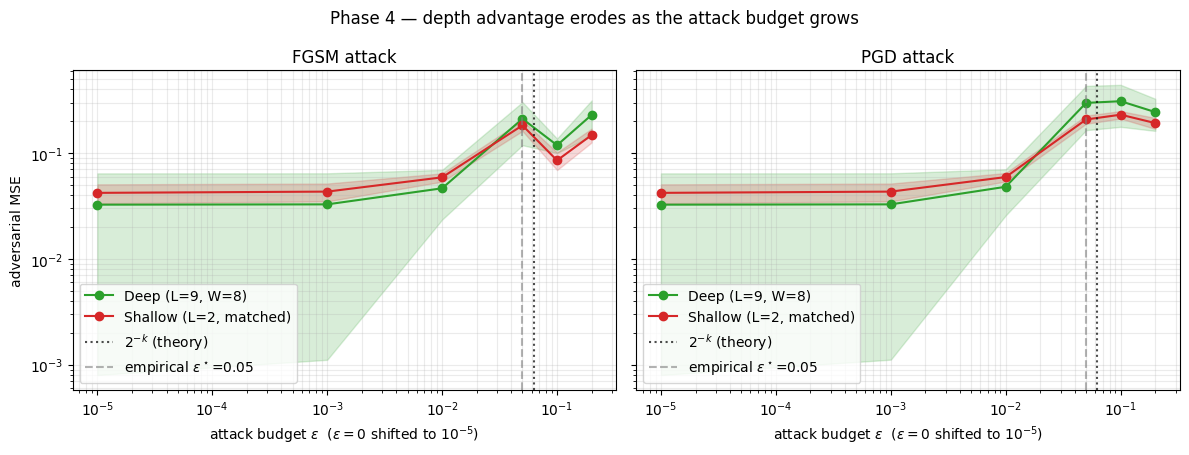

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, attack in zip(axes, ('fgsm', 'pgd')):
    s = summary[attack]
    xs = np.array(EPSILONS, dtype=float)
    xs_plot = np.where(xs == 0, 1e-5, xs)   # log-axis offset
    for mu, sd, color, label in [
        (np.array(s['deep_mu']), np.array(s['deep_sd']), 'tab:green', 'Deep (L=9, W=8)'),
        (np.array(s['shal_mu']), np.array(s['shal_sd']), 'tab:red',   'Shallow (L=2, matched)'),
    ]:
        ax.plot(xs_plot, mu, color=color, marker='o', label=label)
        ax.fill_between(xs_plot, np.maximum(mu - sd, 1e-12), mu + sd, color=color, alpha=0.18)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.axvline(2.0 ** (-K), color='black', linestyle=':', alpha=0.7, label=r'$2^{-k}$ (theory)')
    if s['eps_star'] is not None and s['eps_star'] > 0:
        ax.axvline(s['eps_star'], color='gray', linestyle='--', alpha=0.6, label=fr"empirical $\varepsilon^\star$={s['eps_star']:g}")
    ax.set_title(f'{attack.upper()} attack')
    ax.set_xlabel(r'attack budget $\varepsilon$  ($\varepsilon=0$ shifted to $10^{-5}$)')
    ax.grid(which='both', alpha=0.25); ax.legend()
axes[0].set_ylabel('adversarial MSE')
fig.suptitle('Phase 4 — depth advantage erodes as the attack budget grows')
fig.tight_layout()
fig.savefig(FIG_DIR / 'phase4_adversarial.png', dpi=150)
plt.show()

## 5. Sanity check — visualize a single attack at $\varepsilon = 0.05$

Plot the clean target, deep and shallow predictions on the adversarial inputs. The deep curve should look noticeably *more wiggly* than the shallow one, because every linear region picks up a worst-case displacement.


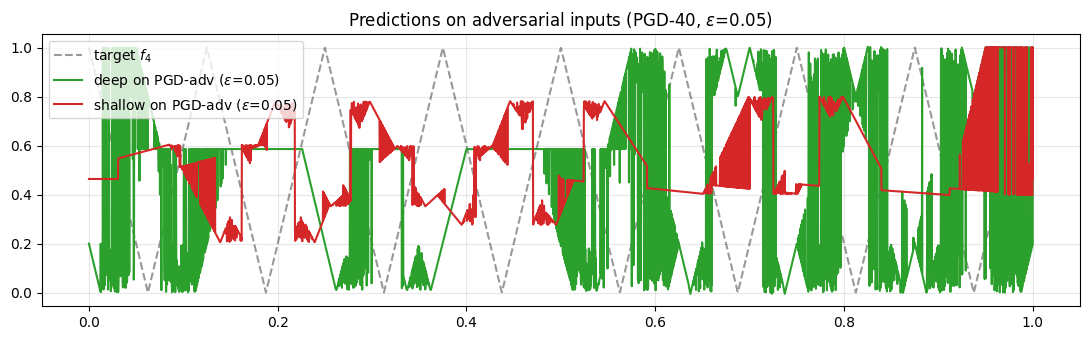

In [8]:
from src.noise import pgd_attack
eps_demo = 0.05
deep0    = deep_models[0]
shallow0 = shallow_models[0]
x_adv_d  = pgd_attack(deep0,    x_eval, y_eval, eps_demo, **PGD_KWARGS)
x_adv_s  = pgd_attack(shallow0, x_eval, y_eval, eps_demo, **PGD_KWARGS)
with torch.no_grad():
    yd = deep0(x_adv_d).cpu().numpy()
    ys = shallow0(x_adv_s).cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(x_eval.cpu(), y_eval.cpu(), 'k--', alpha=0.4, label='target $f_4$')
ax.plot(x_eval.cpu(), yd, color='tab:green', lw=1.5, label=f'deep on PGD-adv ($\\varepsilon$={eps_demo})')
ax.plot(x_eval.cpu(), ys, color='tab:red',   lw=1.5, label=f'shallow on PGD-adv ($\\varepsilon$={eps_demo})')
ax.set_title(f'Predictions on adversarial inputs (PGD-40, $\\varepsilon$={eps_demo})')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'phase4_attack_demo.png', dpi=150)
plt.show()


## 6. Verdict on H4

H4 holds if the empirical $\varepsilon^\star$ from at least one of FGSM / PGD lands within a factor of 2 of the theoretical $2^{-k}=0.0625$.


In [9]:
theory = 2.0 ** (-K)
verdict = {
    'theory_eps_star': theory,
    'fgsm_eps_star':   summary['fgsm']['eps_star'],
    'pgd_eps_star':    summary['pgd' ]['eps_star'],
}
def within_2x(emp):
    return emp is not None and 0.5 * theory <= emp <= 2.0 * theory
verdict['H4_supported'] = bool(within_2x(verdict['fgsm_eps_star']) or within_2x(verdict['pgd_eps_star']))
(TAB_DIR / 'phase4_summary.json').write_text(json.dumps(verdict, indent=2))
verdict


{'theory_eps_star': 0.0625,
 'fgsm_eps_star': 0.05,
 'pgd_eps_star': 0.05,
 'H4_supported': True}